# Credit Card  Default Prediction Using

In [4]:
# impart all libraries
import numpy as np
import pandas as  pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path


In [5]:
pip install xlrd

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd

data = pd.read_excel("data/data_credit.xls")

data.to_csv("data/data_credit.csv", index=False)

data.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [7]:
data=pd.read_csv("data/data_credit.csv")

In [8]:
data.head()

,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [9]:
# Take the first row as column names
data.columns = data.iloc[0]

# Remove the first row
data = data.iloc[1:].reset_index(drop=True)

# Convert all values to numeric
data = data.apply(pd.to_numeric, errors="coerce")

# Check the result
print(data.head())
print(data.columns.tolist())

0  ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1      20000    2          2         1   24      2      2     -1     -1   
1   2     120000    2          2         2   26     -1      2      0      0   
2   3      90000    2          2         2   34      0      0      0      0   
3   4      50000    2          2         1   37      0      0      0      0   
4   5      50000    1          2         1   57     -1      0     -1      0   

0  ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...          0          0          0         0       689         0   
1  ...       3272       3455       3261         0      1000      1000   
2  ...      14331      14948      15549      1518      1500      1000   
3  ...      28314      28959      29547      2000      2019      1200   
4  ...      20940      19146      19131      2000     36681     10000   

0  PAY_AMT4  PAY_AMT5  PAY_AMT6  default payment next month  
0         0         0   

In [40]:
data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,20000,2,2,1,24,2,2,-1,-1,-2,...,0,0,0,0,689,0,0,0,0,1
1,120000,2,2,2,26,-1,2,0,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,90000,2,2,2,34,0,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,50000,2,2,1,37,0,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,50000,1,2,1,57,-1,0,-1,0,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [41]:
data.columns

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month'],
      dtype='object', name=0)

In [12]:
data.shape

(30000, 25)

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

In [14]:
data.isnull().sum().T

0
ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

# EDA

In [42]:
# CORRELATION
correlation=data.corr()['default payment next month'].sort_values(ascending=False)
print(correlation)

0
default payment next month    1.000000
PAY_0                         0.324794
PAY_2                         0.263551
PAY_3                         0.235253
PAY_4                         0.216614
PAY_5                         0.204149
PAY_6                         0.186866
EDUCATION                     0.028006
AGE                           0.013890
BILL_AMT6                    -0.005372
BILL_AMT5                    -0.006760
BILL_AMT4                    -0.010156
BILL_AMT3                    -0.014076
BILL_AMT2                    -0.014193
BILL_AMT1                    -0.019644
MARRIAGE                     -0.024339
SEX                          -0.039961
PAY_AMT6                     -0.053183
PAY_AMT5                     -0.055124
PAY_AMT3                     -0.056250
PAY_AMT4                     -0.056827
PAY_AMT2                     -0.058579
PAY_AMT1                     -0.072929
LIMIT_BAL                    -0.153520
Name: default payment next month, dtype: float64


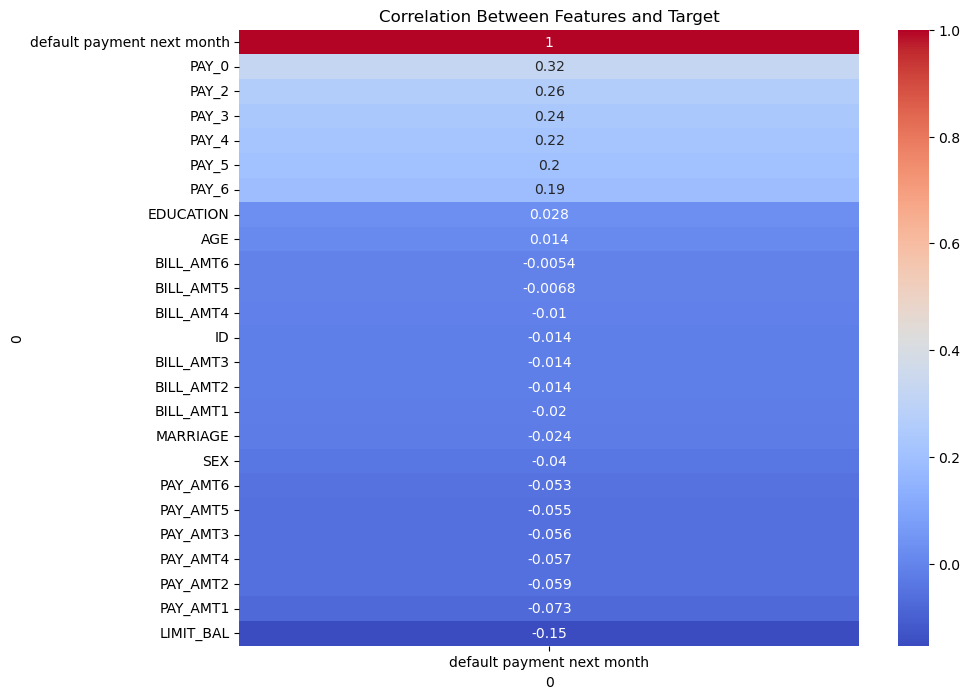

In [16]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    data.corr()[["default payment next month"]].sort_values(
        by="default payment next month",
        ascending=False
    ),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Between Features and Target")
plt.show()

In [17]:
data = data.drop(columns=["ID"])

### spliting X  and y

In [18]:
x=data.drop(columns=['default payment next month'])
y=data['default payment next month']

In [19]:
x.shape

(30000, 23)

In [20]:
y

0        1
1        1
2        0
3        0
4        0
        ..
29995    0
29996    0
29997    1
29998    1
29999    1
Name: default payment next month, Length: 30000, dtype: int64

## train_test_split

In [21]:
from sklearn.model_selection import train_test_split

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.1,train_size=.9,random_state=44,shuffle=True)

## Scaling

In [23]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)

In [24]:
import joblib

joblib.dump(scaler, "helperai_bank_scaler.pkl")

['helperai_bank_scaler.pkl']

### Building Deep Neuron Network

In [25]:
from tensorflow.keras import Sequential,Input
from tensorflow.keras.layers import Dense, Dropout

In [26]:
model = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(64, activation="relu"),
    Dense(128, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,329 (44.25 KB)

 Trainable params: 11,329 (44.25 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [28]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    class_weight={0: 1, 1: 1.5},
    callbacks=[early_stop]
)

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8102 - loss: 0.5873 - val_accuracy: 0.7983 - val_loss: 0.4886
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8133 - loss: 0.5618 - val_accuracy: 0.8178 - val_loss: 0.4629
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8131 - loss: 0.5555 - val_accuracy: 0.8133 - val_loss: 0.4598
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8132 - loss: 0.5502 - val_accuracy: 0.8070 - val_loss: 0.4654
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8156 - loss: 0.5458 - val_accuracy: 0.8080 - val_loss: 0.4617
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8153 - loss: 0.5434 - val_accuracy: 0.8189 - val_loss: 0.4390
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8150 - loss: 0.5402 - val_accuracy: 0.8044 - val_loss: 0.4566
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8167 - loss: 0.5381 - val_accuracy: 0.

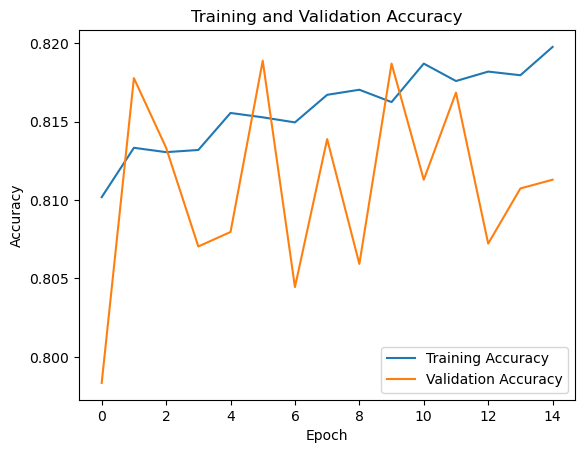

In [29]:
import matplotlib.pyplot as plt

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.show()

In [30]:
test_loss, test_accuracy = model.evaluate(
    x_test_scaled,
    y_test
)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8180 - loss: 0.4283
Test Loss: 0.4282997250556946
Test Accuracy: 0.8180000185966492


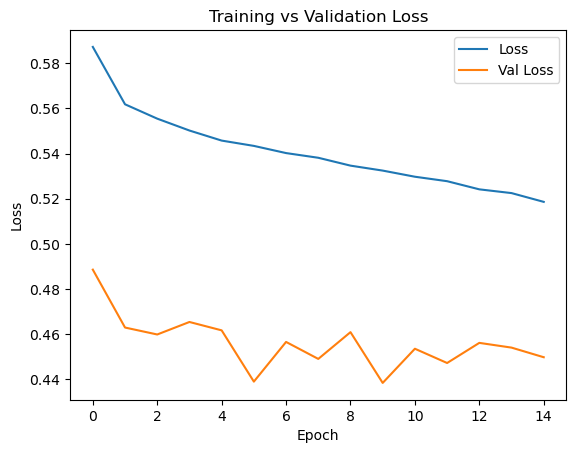

In [31]:
plt.plot(history.history["loss"], label="Loss")
plt.plot(history.history["val_loss"], label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [32]:
y_pred=model.predict(x_test_scaled)

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [33]:
y_pred = (y_pred >= 0.5).astype(int).ravel()

## Evaluation Model 1

In [34]:
from sklearn.metrics import confusion_matrix
model_evalut=confusion_matrix(y_test,y_pred)
model_evalut

array([[2189,  166],
       [ 380,  265]])

In [35]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Accuracy: 0.818
Precision: 0.6148491879350348
Recall: 0.4108527131782946
F1 Score: 0.49256505576208176


In [36]:
plt.Figure(figsize=(8,8))


<Figure size 800x800 with 0 Axes>

In [37]:
y_prob = model.predict(x_test_scaled).ravel()

94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for threshold in [0.5, 0.4, 0.3, 0.2]:
    
    y_pred_threshold = (y_prob >= threshold).astype(int)
    
    print(f"\nThreshold: {threshold}")
    print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1 Score:", f1_score(y_test, y_pred_threshold))


Threshold: 0.5
Accuracy: 0.818
Precision: 0.6148491879350348
Recall: 0.4108527131782946
F1 Score: 0.49256505576208176

Threshold: 0.4
Accuracy: 0.8106666666666666
Precision: 0.5711645101663586
Recall: 0.4790697674418605
F1 Score: 0.521079258010118

Threshold: 0.3
Accuracy: 0.7836666666666666
Precision: 0.49733333333333335
Recall: 0.5782945736434109
F1 Score: 0.5347670250896057

Threshold: 0.2
Accuracy: 0.661
Precision: 0.36181277860326894
Recall: 0.7550387596899225
F1 Score: 0.48920140632847814


## threshold=.4

In [46]:
model.save("credit_default_model.h5")

In [47]:
threshold = 0.4

with open("threshold.txt", "w") as f:
    f.write(str(threshold))

## Model2

In [ ]:

model_2 = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

model_2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,441 (52.50 KB)

 Trainable params: 13,441 (52.50 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model_2.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
early_stop_2 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [ ]:
history_2 = model_2.fit(
    x_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop_2]
)

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.8029 - loss: 0.4755 - val_accuracy: 0.8176 - val_loss: 0.4524
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8149 - loss: 0.4470 - val_accuracy: 0.8191 - val_loss: 0.4466
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8169 - loss: 0.4405 - val_accuracy: 0.8202 - val_loss: 0.4435
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.8187 - loss: 0.4358 - val_accuracy: 0.8200 - val_loss: 0.4419
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 10ms/step - accuracy: 0.8173 - loss: 0.4347 - val_accuracy: 0.8219 - val_loss: 0.4395
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.8196 - loss: 0.4327 - val_accuracy: 0.8211 - val_loss: 0.4372
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8194 - loss: 0.4318 - val_accuracy: 0.8207 - val_loss: 0.4383
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8193 - loss: 0.4314 - val_accuracy:

In [ ]:
y_pred_2=model_2.predict(x_test_scaled)
y_pred_2 = (y_pred_2 >= 0.5).astype(int).ravel()

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [ ]:
from sklearn.metrics import confusion_matrix
model_evalut=confusion_matrix(y_test,y_pred)
model_evalut

array([[2193,  162],
       [ 372,  273]])

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy:", accuracy_score(y_test, y_pred_2))
print("Precision:", precision_score(y_test, y_pred_2))
print("Recall:", recall_score(y_test, y_pred_2))
print("F1 Score:", f1_score(y_test, y_pred_2))

Accuracy: 0.8256666666666667
Precision: 0.6826347305389222
Recall: 0.35348837209302325
F1 Score: 0.46578140960163433


### try1 to improve model

In [ ]:

from tensorflow.keras.optimizers import Adam


model_3 = Sequential([
    Input(shape=(x_train_scaled.shape[1],)),
    
    Dense(128, activation="relu"),
    Dropout(0.3),
    
    Dense(64, activation="relu"),
    Dropout(0.3),
    
    Dense(32, activation="relu"),
    
    Dense(1, activation="sigmoid")
])

model_3.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

early_stop_3 = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history_3 = model_3.fit(
    x_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=64,
    class_weight={0: 1, 1: 1.5},
    callbacks=[early_stop_3]
)

Epoch 1/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7927 - loss: 0.6296 - val_accuracy: 0.8094 - val_loss: 0.4815
Epoch 2/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8105 - loss: 0.5926 - val_accuracy: 0.8120 - val_loss: 0.4742
Epoch 3/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8117 - loss: 0.5797 - val_accuracy: 0.8115 - val_loss: 0.4656
Epoch 4/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8128 - loss: 0.5710 - val_accuracy: 0.8143 - val_loss: 0.4561
Epoch 5/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8112 - loss: 0.5696 - val_accuracy: 0.8146 - val_loss: 0.4521
Epoch 6/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8132 - loss: 0.5631 - val_accuracy: 0.8130 - val_loss: 0.4552
Epoch 7/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8126 - loss: 0.5596 - val_accuracy: 0.8152 - val_loss: 0.4528
Epoch 8/50
338/338 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.8136 - loss: 0.5597 - val_accuracy

In [ ]:
y_prob_3 = model_3.predict(x_test_scaled).ravel()
y_pred_3 = (y_prob_3 >= 0.5).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", accuracy_score(y_test, y_pred_3))
print("Precision:", precision_score(y_test, y_pred_3))
print("Recall:", recall_score(y_test, y_pred_3))
print("F1 Score:", f1_score(y_test, y_pred_3))

94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Accuracy: 0.8243333333333334
Precision: 0.6260683760683761
Recall: 0.4542635658914729
F1 Score: 0.5265049415992812


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

for threshold in [0.5, 0.4, 0.3, 0.2]:
    
    y_pred_threshold = (y_prob_3 >= threshold).astype(int)
    
    print(f"\nThreshold: {threshold}")
    print("Accuracy:", accuracy_score(y_test, y_pred_threshold))
    print("Precision:", precision_score(y_test, y_pred_threshold))
    print("Recall:", recall_score(y_test, y_pred_threshold))
    print("F1 Score:", f1_score(y_test, y_pred_threshold))


Threshold: 0.5
Accuracy: 0.8243333333333334
Precision: 0.6260683760683761
Recall: 0.4542635658914729
F1 Score: 0.5265049415992812

Threshold: 0.4
Accuracy: 0.8096666666666666
Precision: 0.5642361111111112
Recall: 0.5038759689922481
F1 Score: 0.5323505323505323

Threshold: 0.3
Accuracy: 0.7773333333333333
Precision: 0.4854614412136536
Recall: 0.5953488372093023
F1 Score: 0.5348189415041783

Threshold: 0.2
Accuracy: 0.6006666666666667
Precision: 0.3242212333121424
Recall: 0.7906976744186046
F1 Score: 0.4598737601442741
